In [2]:
!pip install pandas numpy bokeh xgboost shap scikit-learn matplotlib --quiet


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import time

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import shap
import matplotlib.pyplot as plt

from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource

output_notebook()
print("All imports done!")

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading BokehJS ...

All imports done!


In [4]:
df = pd.read_csv("dataset.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (18368, 12)


,ID,SystemCodeNumber,Capacity,Latitude,Longitude,Occupancy,VehicleType,TrafficConditionNearby,QueueLength,IsSpecialDay,LastUpdatedDate,LastUpdatedTime
0,0,BHMBCCMKT01,577,26.144536,91.736172,61,car,low,1,0,04-10-2016,07:59:00
1,1,BHMBCCMKT01,577,26.144536,91.736172,64,car,low,1,0,04-10-2016,08:25:00
2,2,BHMBCCMKT01,577,26.144536,91.736172,80,car,low,2,0,04-10-2016,08:59:00
3,3,BHMBCCMKT01,577,26.144536,91.736172,107,car,low,2,0,04-10-2016,09:32:00
4,4,BHMBCCMKT01,577,26.144536,91.736172,150,bike,low,2,0,04-10-2016,09:59:00


In [5]:
df_prices = df.copy()

# Timestamp
df_prices['Timestamp'] = pd.to_datetime(
    df_prices['LastUpdatedDate'] + ' ' + df_prices['LastUpdatedTime'],
    format="%d-%m-%Y %H:%M:%S"
)

# Occupancy ratio
df_prices['OccRatio'] = df_prices['Occupancy'] / df_prices['Capacity'].replace(0, 1)

# Traffic → numeric
traffic_map = {"Low": 0.0, "Medium": 0.5, "High": 1.0}
df_prices['TrafficNum'] = df_prices['TrafficConditionNearby'].map(traffic_map).fillna(0.5)

# Vehicle type → weight
vehicle_map = {"car": 1.0, "bike": 0.7, "truck": 1.3}
df_prices['VehicleWeight'] = df_prices['VehicleType'].map(vehicle_map).fillna(1.0)

# Demand score
ALPHA = 1.2; BETA = 0.7; GAMMA = 0.5; DELTA = 0.8; EPSILON = 0.5

df_prices['DemandScore'] = (
    ALPHA * df_prices['OccRatio'] +
    BETA  * df_prices['QueueLength'] / 10 +
    DELTA * df_prices['IsSpecialDay'] +
    EPSILON * df_prices['VehicleWeight'] -
    GAMMA * df_prices['TrafficNum']
)

# Normalize and compute price
df_prices['NormDemand'] = df_prices['DemandScore'].clip(0, 2)
BASE_PRICE = 10; LAMBDA = 0.5
df_prices['RawPrice'] = BASE_PRICE * (1 + LAMBDA * df_prices['NormDemand'])
df_prices['Price'] = df_prices['RawPrice'].clip(5, 20)

df_prices = df_prices.sort_values('Timestamp').reset_index(drop=True)

print(f"Shape: {df_prices.shape}")
df_prices.head()

Shape: (18368, 20)


,ID,SystemCodeNumber,Capacity,Latitude,Longitude,Occupancy,VehicleType,TrafficConditionNearby,QueueLength,IsSpecialDay,LastUpdatedDate,LastUpdatedTime,Timestamp,OccRatio,TrafficNum,VehicleWeight,DemandScore,NormDemand,RawPrice,Price
0,0,BHMBCCMKT01,577,26.144536,91.736172,61,car,low,1,0,04-10-2016,07:59:00,2016-10-04 07:59:00,0.105719,0.5,1.0,0.446863,0.446863,12.234315,12.234315
1,5248,BHMNCPHST01,1200,26.140014,91.731000,237,bike,low,2,0,04-10-2016,07:59:00,2016-10-04 07:59:00,0.197500,0.5,0.7,0.477000,0.477000,12.385000,12.385000
2,3936,BHMMBMMBX01,687,20.000035,78.000003,264,car,low,2,0,04-10-2016,07:59:00,2016-10-04 07:59:00,0.384279,0.5,1.0,0.851135,0.851135,14.255677,14.255677
3,6560,BHMNCPNST01,485,26.140048,91.730972,249,car,low,2,0,04-10-2016,07:59:00,2016-10-04 07:59:00,0.513402,0.5,1.0,1.006082,1.006082,15.030412,15.030412
4,17056,Shopping,1920,26.150504,91.733531,614,cycle,low,2,0,04-10-2016,07:59:00,2016-10-04 07:59:00,0.319792,0.5,1.0,0.773750,0.773750,13.868750,13.868750


In [6]:
df_prices['Hour'] = df_prices['Timestamp'].dt.hour
df_prices['IsWeekend'] = (df_prices['Timestamp'].dt.dayofweek >= 5).astype(int)

print("Hour and IsWeekend added!")
print(f"Hour range: {df_prices['Hour'].min()} to {df_prices['Hour'].max()}")
print(f"Weekend rows: {df_prices['IsWeekend'].sum()} out of {len(df_prices)}")
df_prices[['Timestamp', 'Hour', 'IsWeekend', 'Price']].head()

Hour and IsWeekend added!
Hour range: 7 to 16
Weekend rows: 5040 out of 18368


,Timestamp,Hour,IsWeekend,Price
0,2016-10-04 07:59:00,7,0,12.234315
1,2016-10-04 07:59:00,7,0,12.385000
2,2016-10-04 07:59:00,7,0,14.255677
3,2016-10-04 07:59:00,7,0,15.030412
4,2016-10-04 07:59:00,7,0,13.868750


In [7]:
FEATURES = ['OccRatio', 'QueueLength', 'TrafficNum', 'VehicleWeight',
            'IsSpecialDay', 'DemandScore', 'Hour', 'IsWeekend']
TARGET = 'Price'

X = df_prices[FEATURES]
y = df_prices[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print(f"Features   : {FEATURES}")

Train size : 14694
Test size  : 3674
Features   : ['OccRatio', 'QueueLength', 'TrafficNum', 'VehicleWeight', 'IsSpecialDay', 'DemandScore', 'Hour', 'IsWeekend']


In [8]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression done")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest done")

# XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost done")

/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Linear Regression done
Random Forest done
XGBoost done


In [9]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": round(rmse, 4), "MAE": round(mae, 4), "R²": round(r2, 4)}

results = pd.DataFrame([
    evaluate("Linear Regression", y_test, y_pred_lr),
    evaluate("Random Forest",     y_test, y_pred_rf),
    evaluate("XGBoost",           y_test, y_pred_xgb),
])

print("========= Model Comparison =========")
print(results.to_string(index=False))
print(f"\nBest model: {results.loc[results['R²'].idxmax(), 'Model']}")

========= Model Comparison =========
            Model   RMSE    MAE     R²
Linear Regression 0.5942 0.2400 0.9267
    Random Forest 0.0041 0.0005 1.0000
          XGBoost 0.0133 0.0089 1.0000

Best model: Random Forest


In [11]:
best_name = results.loc[results['R²'].idxmax(), 'Model']
best_preds = {"Linear Regression": y_pred_lr,
              "Random Forest": y_pred_rf,
              "XGBoost": y_pred_xgb}[best_name]

source_scatter = ColumnDataSource(dict(
    actual=list(y_test),
    predicted=list(best_preds)
))

p = figure(
    title=f"Actual vs Predicted Price ({best_name})",
    x_axis_label="Actual Price ($)",
    y_axis_label="Predicted Price ($)",
    width=600, height=500,
    tools="pan,wheel_zoom,box_zoom,reset"
)

p.circle('actual', 'predicted', source=source_scatter,
         size=4, color='steelblue', alpha=0.5, legend_label="Predictions")

price_min = float(y_test.min())
price_max = float(y_test.max())
p.line([price_min, price_max], [price_min, price_max],
       color='red', line_width=2, line_dash='dashed', legend_label="Perfect Prediction")

p.legend.location = 'top_left'
p.grid.grid_line_alpha = 0.3
show(p)

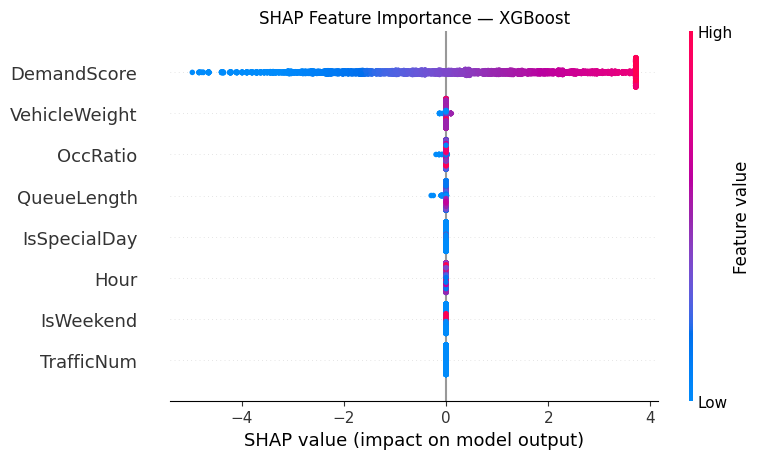

Saved as shap_summary.png


In [10]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved as shap_summary.png")

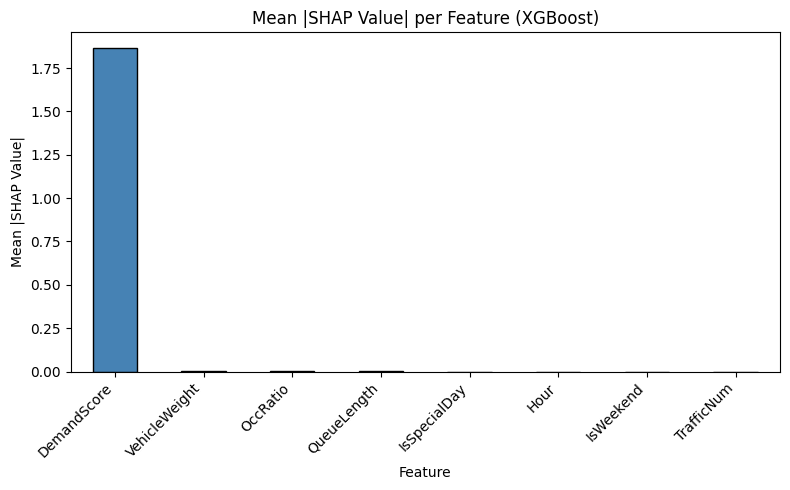


Top 3 pricing drivers:
  1. DemandScore  (mean |SHAP| = 1.8628)
  2. VehicleWeight  (mean |SHAP| = 0.0011)
  3. OccRatio  (mean |SHAP| = 0.0010)


In [11]:
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
mean_shap.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Mean |SHAP Value| per Feature (XGBoost)")
plt.ylabel("Mean |SHAP Value|")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 pricing drivers:")
for i, (feat, val) in enumerate(mean_shap.head(3).items(), 1):
    print(f"  {i}. {feat}  (mean |SHAP| = {val:.4f})")

In [12]:
print("=" * 45)
print("        FINAL MODEL COMPARISON")
print("=" * 45)
print(results.to_string(index=False))
print("=" * 45)
print(f"Best model : {best_name}")
print(f"Best R²    : {results['R²'].max()}")
print("=" * 45)
print("\nTop pricing drivers (SHAP):")
for i, (feat, val) in enumerate(mean_shap.head(3).items(), 1):
    print(f"  {i}. {feat}  ({val:.4f})")

        FINAL MODEL COMPARISON
            Model   RMSE    MAE     R²
Linear Regression 0.5942 0.2400 0.9267
    Random Forest 0.0041 0.0005 1.0000
          XGBoost 0.0133 0.0089 1.0000
Best model : Random Forest
Best R²    : 1.0

Top pricing drivers (SHAP):
  1. DemandScore  (1.8628)
  2. VehicleWeight  (0.0011)
  3. OccRatio  (0.0010)
